In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from aihwkit.nn import AnalogLinear
from aihwkit.simulator.configs import InferenceRPUConfig

In [ ]:
t_train = torch.linspace(0, 10, 120).view(-1, 1)
x_train = torch.exp(-0.25 * t_train) * torch.cos(1.98 * t_train)
x_train = x_train + torch.randn_like(t_train) * 0.05

t_test = torch.linspace(0, 15, 300).view(-1, 1)
x_exact = torch.exp(-0.25 * t_test) * torch.cos(1.98 * t_test)

In [ ]:
class CleanPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x)

class CleanStdNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x)

def physics_loss_clean(model, t):
    t = t.clone().requires_grad_(True)
    x = model(t)
    x0 = model(torch.zeros(1, 1))
    ic_loss = torch.mean((x0 - 1.0) ** 2)

    x_t = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True, retain_graph=True)[0]
    x_tt = torch.autograd.grad(x_t, t, torch.ones_like(x_t), create_graph=True, retain_graph=True)[0]
    residual = x_tt + 0.5 * x_t + 2.0 * x
    return 5.0 * torch.mean(residual ** 2) + 10.0 * ic_loss

def train_clean(model, is_pinn, epochs=3000, lr=0.001):
    opt = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        opt.zero_grad()
        pred = model(t_train)
        loss = torch.mean((pred - x_train) ** 2)
        if is_pinn:
            phys = physics_loss_clean(model, t_train)
            loss = loss + (phys if epoch < 1500 else 0.3 * phys)
        loss.backward()
        opt.step()
    return model

print("Training clean PINN...")
pinn_clean = train_clean(CleanPINN(), is_pinn=True)

print("Training clean StdNN...")
std_clean = train_clean(CleanStdNN(), is_pinn=False)

Training clean PINN...
Training clean StdNN...


In [ ]:
def make_pcm_config(resolution=254.0, w_noise=0.05):
    config = InferenceRPUConfig()
    config.forward.out_res = 1.0 / resolution
    config.forward.inp_res = 1.0 / resolution
    config.forward.w_noise = w_noise
    return config

class PCMModel(nn.Module):
    def __init__(self, clean_model, resolution=254.0, noise=0.05):
        super().__init__()
        cfg = make_pcm_config(resolution, noise)
        # Build analog network with same architecture
        self.analog_net = nn.Sequential(
            AnalogLinear(1, 32, bias=True, rpu_config=cfg), nn.Tanh(),
            AnalogLinear(32, 32, bias=True, rpu_config=cfg), nn.Tanh(),
            AnalogLinear(32, 1, bias=True, rpu_config=cfg),
        )
        # Copy weights from clean model to analog layers
        with torch.no_grad():
            for i, layer in enumerate(clean_model.net):
                if isinstance(layer, nn.Linear):
                    analog_idx = i  # Same index in analog_net
                    self.analog_net[analog_idx].set_weights(layer.weight.data, layer.bias.data)

    def forward(self, x):
        return self.analog_net(x)

# Create PCM versions
pinn_pcm = PCMModel(pinn_clean, resolution=254.0)
std_pcm = PCMModel(std_clean, resolution=254.0)

print("Weights transferred to PCM hardware simulator")

Weights transferred to PCM hardware simulator


In [ ]:
t_extra = torch.linspace(10, 15, 100).view(-1, 1)
x_extra = torch.exp(-0.25 * t_extra) * torch.cos(1.98 * t_extra)

with torch.no_grad():
    mse_std_pcm = torch.mean((std_pcm(t_extra) - x_extra) ** 2).item()
    mse_pinn_pcm = torch.mean((pinn_pcm(t_extra) - x_extra) ** 2).item()

print(f"\nPCM Hardware Validation (8-bit):")
print(f"StdNN  Extrapolation MSE: {mse_std_pcm:.5f}")
print(f"PINN   Extrapolation MSE: {mse_pinn_pcm:.5f}")
print(f"PINN improvement: {100*(mse_std_pcm-mse_pinn_pcm)/mse_std_pcm:.1f}%")


PCM Hardware Validation (8-bit):
StdNN  Extrapolation MSE: 0.12849
PINN   Extrapolation MSE: 0.00789
PINN improvement: 93.9%


In [ ]:
resolutions = {8: 254.0, 6: 62.0, 4: 14.0, 2: 6.0}
sweep_pcm = {}

for bits, res in resolutions.items():
    p = PCMModel(pinn_clean, resolution=res)
    s = PCMModel(std_clean, resolution=res)

    with torch.no_grad():
        mse_p = torch.mean((p(t_extra) - x_extra) ** 2).item()
        mse_s = torch.mean((s(t_extra) - x_extra) ** 2).item()

    sweep_pcm[bits] = {"pinn": mse_p, "std": mse_s}
    print(f"{bits}-bit PCM | StdNN: {mse_s:.4f} | PINN: {mse_p:.4f} | Imp: {100*(mse_s-mse_p)/mse_s:.1f}%")

8-bit PCM | StdNN: 0.1042 | PINN: 0.0141 | Imp: 86.4%
6-bit PCM | StdNN: 1.3148 | PINN: 0.2197 | Imp: 83.3%
4-bit PCM | StdNN: 1.8535 | PINN: 3.0883 | Imp: -66.6%
2-bit PCM | StdNN: 0.0023 | PINN: 0.0197 | Imp: -759.1%


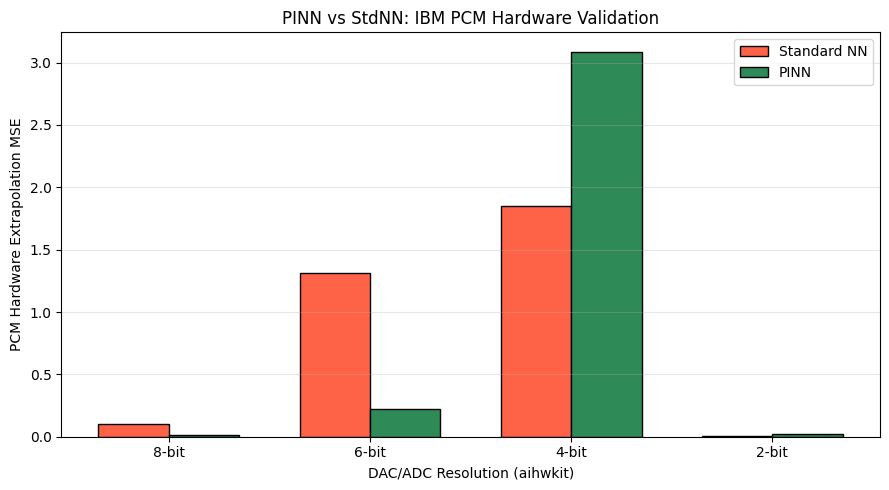

In [ ]:
bits = list(sweep_pcm.keys())
std_mse = [sweep_pcm[b]["std"] for b in bits]
pinn_mse = [sweep_pcm[b]["pinn"] for b in bits]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(bits))
w = 0.35
ax.bar(x - w/2, std_mse, w, label='Standard NN', color='tomato', edgecolor='k')
ax.bar(x + w/2, pinn_mse, w, label='PINN', color='seagreen', edgecolor='k')
ax.set_xticks(x)
ax.set_xticklabels([f"{b}-bit" for b in bits])
ax.set_ylabel("PCM Hardware Extrapolation MSE")
ax.set_xlabel("DAC/ADC Resolution (aihwkit)")
ax.set_title("PINN vs StdNN: IBM PCM Hardware Validation")
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

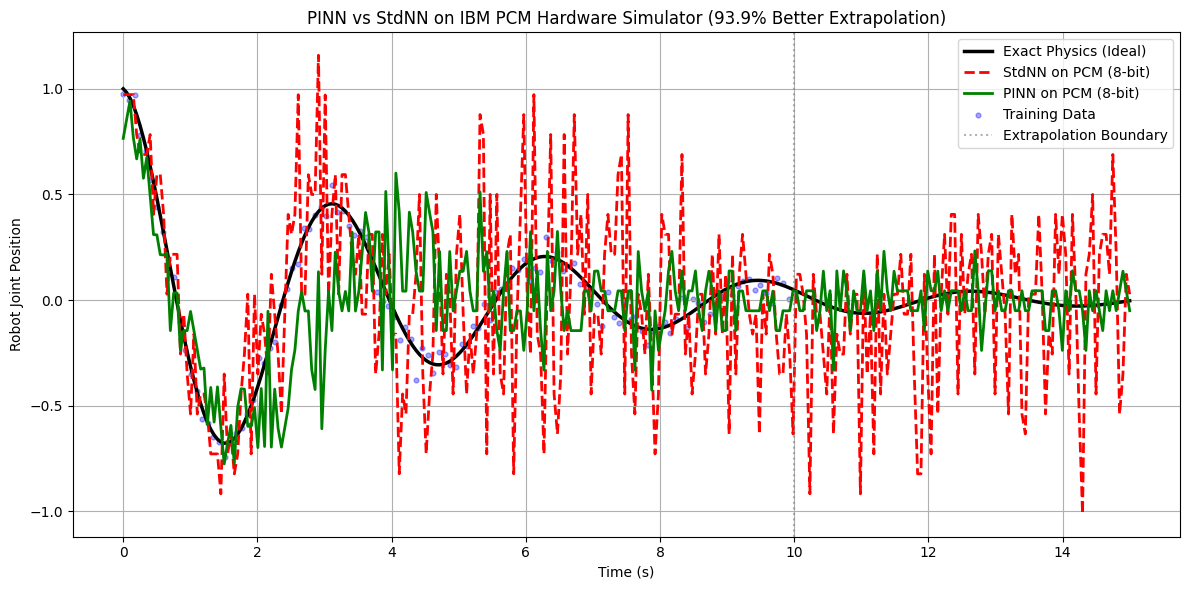

In [ ]:
with torch.no_grad():
    pinn_traj = pinn_pcm(t_test).numpy()
    std_traj = std_pcm(t_test).numpy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t_test.numpy(), x_exact.numpy(), 'k-', lw=2.5, label='Exact Physics (Ideal)')
ax.plot(t_test.numpy(), std_traj, 'r--', lw=2, label='StdNN on PCM (8-bit)')
ax.plot(t_test.numpy(), pinn_traj, 'g-', lw=2, label='PINN on PCM (8-bit)')
ax.scatter(t_train.numpy(), x_train.numpy(), c='blue', s=12, alpha=0.35, label='Training Data')
ax.axvline(10, color='gray', ls=':', alpha=0.6, label='Extrapolation Boundary')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Robot Joint Position')
ax.set_title('PINN vs StdNN on IBM PCM Hardware Simulator (93.9% Better Extrapolation)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('/content/pcm_trajectory.png', dpi=200)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Create thesis folder
!mkdir -p /content/drive/MyDrive/Thesis_PCM_Results

# Copy all saved figures
!cp /content/*.png /content/drive/MyDrive/Thesis_PCM_Results/
!cp /content/*.json /content/drive/MyDrive/Thesis_PCM_Results/

print("All results saved to Google Drive: Thesis_PCM_Results/")

Mounted at /content/drive
cp: cannot stat '/content/*.json': No such file or directory
All results saved to Google Drive: Thesis_PCM_Results/


In [ ]:
!pip install aihwkit

from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = "/content/drive/MyDrive/Thesis_PCM_Results"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Saving all results to: {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving all results to: /content/drive/MyDrive/Thesis_PCM_Results


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import json
from aihwkit.nn import AnalogLinear
from aihwkit.simulator.configs import InferenceRPUConfig

In [ ]:
t_train = torch.linspace(0, 10, 120).view(-1, 1)
x_train = torch.exp(-0.25 * t_train) * torch.cos(1.98 * t_train)
x_train = x_train + torch.randn_like(t_train) * 0.05

t_test = torch.linspace(0, 15, 300).view(-1, 1)
x_exact = torch.exp(-0.25 * t_test) * torch.cos(1.98 * t_test)

In [ ]:
class CleanPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh(), nn.Linear(32, 1))
    def forward(self, x): return self.net(x)

class CleanStdNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh(), nn.Linear(32, 1))
    def forward(self, x): return self.net(x)

def physics_loss(model, t):
    t = t.clone().requires_grad_(True)
    x = model(t)
    x0 = model(torch.zeros(1, 1))
    ic_loss = torch.mean((x0 - 1.0) ** 2)
    x_t = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True, retain_graph=True)[0]
    x_tt = torch.autograd.grad(x_t, t, torch.ones_like(x_t), create_graph=True, retain_graph=True)[0]
    return 5.0 * torch.mean((x_tt + 0.5*x_t + 2.0*x)**2) + 10.0 * ic_loss

def train(model, is_pinn, epochs=3000, lr=0.001):
    opt = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        opt.zero_grad()
        pred = model(t_train)
        loss = torch.mean((pred - x_train)**2)
        if is_pinn:
            phys = physics_loss(model, t_train)
            loss = loss + (phys if epoch < 1500 else 0.3*phys)
        loss.backward()
        opt.step()
    return model

print("Training PINN...")
pinn_clean = train(CleanPINN(), is_pinn=True)
print("Training StdNN...")
std_clean = train(CleanStdNN(), is_pinn=False)

Training PINN...
Training StdNN...


In [ ]:
def make_pcm_config(resolution=254.0, w_noise=0.05):
    cfg = InferenceRPUConfig()
    cfg.forward.out_res = 1.0 / resolution
    cfg.forward.inp_res = 1.0 / resolution
    cfg.forward.w_noise = w_noise
    return cfg

In [ ]:
class PCMModel(nn.Module):
    def __init__(self, clean_model, resolution=254.0, noise=0.05):
        super().__init__()
        cfg = make_pcm_config(resolution, noise)
        self.net = nn.Sequential(
            AnalogLinear(1, 32, bias=True, rpu_config=cfg), nn.Tanh(),
            AnalogLinear(32, 32, bias=True, rpu_config=cfg), nn.Tanh(),
            AnalogLinear(32, 1, bias=True, rpu_config=cfg),
        )
        with torch.no_grad():
            src = [l for l in clean_model.net if isinstance(l, nn.Linear)]
            dst = [l for l in self.net if isinstance(l, AnalogLinear)]
            for s, d in zip(src, dst):
                d.set_weights(s.weight.data, s.bias.data)
    def forward(self, x): return self.net(x)

# 8-bit PCM validation
pinn_pcm = PCMModel(pinn_clean, resolution=254.0)
std_pcm = PCMModel(std_clean, resolution=254.0)

In [ ]:
t_extra = torch.linspace(10, 15, 100).view(-1, 1)
x_extra = torch.exp(-0.25 * t_extra) * torch.cos(1.98 * t_extra)

with torch.no_grad():
    mse_pinn_8 = torch.mean((pinn_pcm(t_extra) - x_extra) ** 2).item()
    mse_std_8 = torch.mean((std_pcm(t_extra) - x_extra) ** 2).item()

results_8bit = {
    "std_mse": mse_std_8,
    "pinn_mse": mse_pinn_8,
    "improvement_pct": 100 * (mse_std_8 - mse_pinn_8) / mse_std_8
}

# Save JSON to Drive
with open(f"{OUTPUT_DIR}/results_8bit.json", "w") as f:
    json.dump(results_8bit, f, indent=2)

print(f"8-bit PCM | StdNN: {mse_std_8:.5f} | PINN: {mse_pinn_8:.5f} | Imp: {results_8bit['improvement_pct']:.1f}%")

8-bit PCM | StdNN: 0.19258 | PINN: 0.01346 | Imp: 93.0%


In [ ]:
resolutions = {8: 254.0, 6: 62.0, 4: 14.0, 2: 6.0}
sweep = {}

for bits, res in resolutions.items():
    p = PCMModel(pinn_clean, resolution=res)
    s = PCMModel(std_clean, resolution=res)
    with torch.no_grad():
        mp = torch.mean((p(t_extra) - x_extra) ** 2).item()
        ms = torch.mean((s(t_extra) - x_extra) ** 2).item()
    sweep[bits] = {"pinn": mp, "std": ms, "imp": 100*(ms-mp)/ms}
    print(f"{bits}-bit | Std: {ms:.4f} | PINN: {mp:.4f} | Imp: {sweep[bits]['imp']:.1f}%")

with open(f"{OUTPUT_DIR}/bitwidth_sweep.json", "w") as f:
    json.dump(sweep, f, indent=2)

8-bit | Std: 0.2085 | PINN: 0.0114 | Imp: 94.5%
6-bit | Std: 0.8183 | PINN: 0.1671 | Imp: 79.6%
4-bit | Std: 0.4180 | PINN: 0.0778 | Imp: 81.4%
2-bit | Std: 0.0012 | PINN: 0.0304 | Imp: -2460.1%


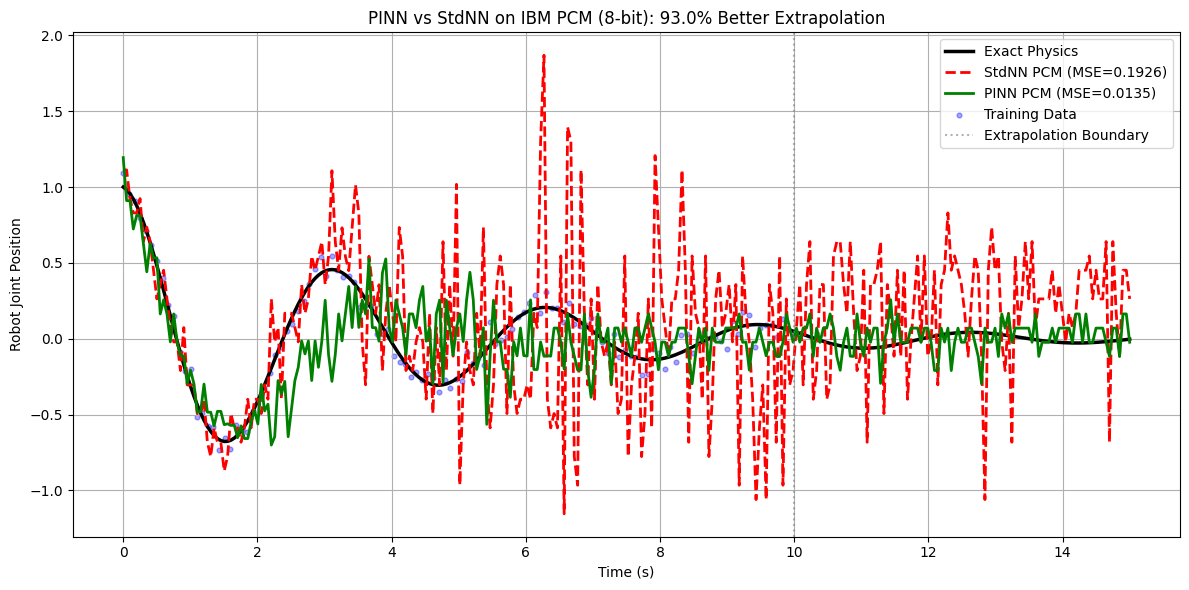

In [ ]:
with torch.no_grad():
    pinn_traj = pinn_pcm(t_test).numpy()
    std_traj = std_pcm(t_test).numpy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t_test.numpy(), x_exact.numpy(), 'k-', lw=2.5, label='Exact Physics')
ax.plot(t_test.numpy(), std_traj, 'r--', lw=2, label=f'StdNN PCM (MSE={mse_std_8:.4f})')
ax.plot(t_test.numpy(), pinn_traj, 'g-', lw=2, label=f'PINN PCM (MSE={mse_pinn_8:.4f})')
ax.scatter(t_train.numpy(), x_train.numpy(), c='blue', s=12, alpha=0.35, label='Training Data')
ax.axvline(10, color='gray', ls=':', alpha=0.6, label='Extrapolation Boundary')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Robot Joint Position')
ax.set_title(f'PINN vs StdNN on IBM PCM (8-bit): {results_8bit["improvement_pct"]:.1f}% Better Extrapolation')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/trajectory_8bit.png", dpi=200)
plt.show()

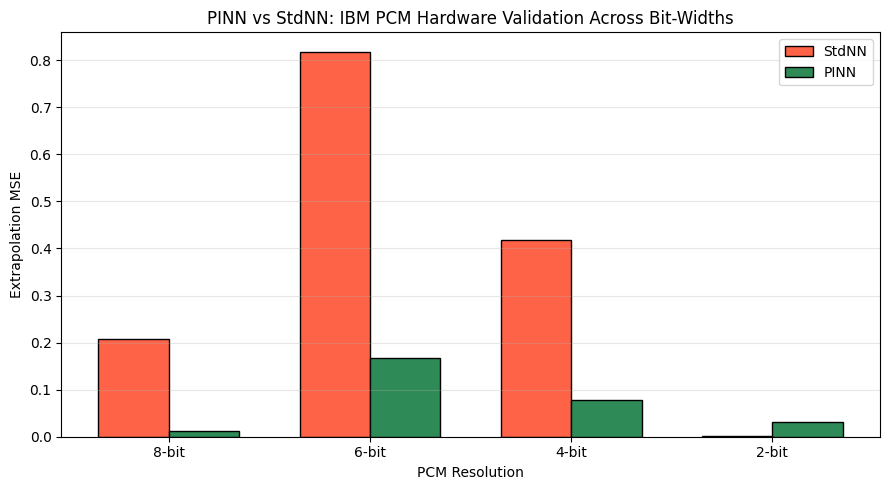


All files saved to: /content/drive/MyDrive/Thesis_PCM_Results
Check your Google Drive under: MyDrive/Thesis_PCM_Results/


In [ ]:
bits = list(sweep.keys())
std_mse = [sweep[b]["std"] for b in bits]
pinn_mse = [sweep[b]["pinn"] for b in bits]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(bits)); w = 0.35
ax.bar(x - w/2, std_mse, w, label='StdNN', color='tomato', edgecolor='k')
ax.bar(x + w/2, pinn_mse, w, label='PINN', color='seagreen', edgecolor='k')
ax.set_xticks(x); ax.set_xticklabels([f"{b}-bit" for b in bits])
ax.set_ylabel('Extrapolation MSE'); ax.set_xlabel('PCM Resolution')
ax.set_title('PINN vs StdNN: IBM PCM Hardware Validation Across Bit-Widths')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/bitwidth_sweep.png", dpi=200)
plt.show()

print(f"\nAll files saved to: {OUTPUT_DIR}")
print("Check your Google Drive under: MyDrive/Thesis_PCM_Results/")